In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from scipy.integrate import quad
from scipy.constants import epsilon_0
from functools import lru_cache
from IPython.display import display, Markdown, Math, HTML

from optomechanics_levitation import (
    particle_properties,
    input_beam_waist_from_filling_factor,
    electric_field_amplitude_from_power,
    evaluate_incident_field,
    hermite_gauss_00,
    evaluate_internal_field,
    evaluate_near_field,
)
from optomechanics_levitation.particle import rotate_particle
from optomechanics_levitation.light_matter_interaction import total_fields
from optomechanics_levitation.observables import (
    maxwell_stress_tensor,
    spherical_integration_surface,
    evaluate_torque,
)

In [11]:
@lru_cache(maxsize=None)
def depolarization_factors(aspect_ratio):
    a_norm = 1.0 / aspect_ratio
    b_norm = 1.0 / aspect_ratio
    c_norm = 1.0

    def f_q(q, a, b, c):
        return np.sqrt((q + a**2) * (q + b**2) * (q + c**2))

    L_1 = a_norm * b_norm * c_norm * quad(lambda q: 1 / ((a_norm**2 + q) * f_q(q, a_norm, b_norm, c_norm)), 0, np.inf)[0] / 2
    L_3 = a_norm * b_norm * c_norm * quad(lambda q: 1 / ((c_norm**2 + q) * f_q(q, a_norm, b_norm, c_norm)), 0, np.inf)[0] / 2
    L_2 = L_1

    return L_1, L_2, L_3

def focused_peak_efield(hermitegauss_params, equilibrium_z_nm):
    focus_params = dict(hermitegauss_params, positions_nm=np.array([[0.0, 0.0, equilibrium_z_nm]]), field="E")
    focus_efield = evaluate_incident_field(field_generator=hermite_gauss_00, **focus_params)
    return np.linalg.norm(focus_efield[0])

def theoretical_libration_frequency(long_axis_nm, aspect_ratio, peak_efield, density=2200.0, n_silica=1.444, n_medium=1.0):
    long_axis = long_axis_nm * 1e-9
    a = long_axis / (2 * aspect_ratio)
    b = long_axis / (2 * aspect_ratio)
    c = long_axis / 2

    mass = 4 * np.pi * a * b * c * density / 3
    inertia_moment = mass * (a**2 + c**2) / 5

    L_1, _, L_3 = depolarization_factors(aspect_ratio)

    epsilon_1 = n_silica**2
    epsilon_m = n_medium**2

    alpha_1 = 4 * np.pi * epsilon_0 * epsilon_m * a * b * c * (epsilon_1 - epsilon_m) / (3 * epsilon_m + 3 * L_1 * (epsilon_1 - epsilon_m))
    alpha_3 = 4 * np.pi * epsilon_0 * epsilon_m * a * b * c * (epsilon_1 - epsilon_m) / (3 * epsilon_m + 3 * L_3 * (epsilon_1 - epsilon_m))

    delta_alpha = np.real(alpha_3 - alpha_1)

    lib_angular_freq = peak_efield * np.sqrt(delta_alpha / (2 * inertia_moment))
    lib_freq_kHz = lib_angular_freq / (2 * np.pi * 1e3)

    return lib_freq_kHz

In [12]:
# Particle and material
long_axis_nm = 100.0
aspect_ratio = 4.0

if aspect_ratio == 2.0:
    step_nm = long_axis_nm / 25.0
else: 
    step_nm = long_axis_nm / 50.0 

density = 2200.0
n_silica = 1.444

# Optical setup
wavelength_nm = 1550.0
NA = 0.75
f_mm = 3.0
filling_factor = 1.0
optical_power_W = 1.0
equilibrium_z_nm = 0.0
n_medium = 1.0
impedance_ohms = 376.730313668

w0_mm = input_beam_waist_from_filling_factor(
    filling_factor=filling_factor, numerical_aperture=NA,
    focal_length_mm=f_mm, refractive_index=n_medium
)
profile_power_integral_m2 = np.pi * (w0_mm * 1e-3)**2 / 2
amplitude_v_per_m = electric_field_amplitude_from_power(
    power_w=optical_power_W,
    profile_power_integral_m2=profile_power_integral_m2,
    impedance_ohms=impedance_ohms
)

hermitegauss_params = dict(
    wavelength_nm=wavelength_nm,
    environment={"eps1": n_medium**2, "eps2": n_medium**2, "eps3": n_medium**2},
    amplitude_v_per_m=amplitude_v_per_m,
    theta=0, NA=NA, f=f_mm, w0=w0_mm,
    xSpot=0, ySpot=0, zSpot=0, kSign=-1, phase=0,
    quadrature_points=24, N_cpu=4
)

In [13]:
focus_position_nm = np.array([[0.0, 0.0, equilibrium_z_nm]])

focus_efield = evaluate_incident_field(
    field_generator=hermite_gauss_00,
    positions_nm=focus_position_nm,
    field="E",
    **hermitegauss_params
)
peak_efield = np.linalg.norm(focus_efield[0])

theoretical_freq_kHz = theoretical_libration_frequency(
    long_axis_nm=long_axis_nm,
    aspect_ratio=aspect_ratio,
    peak_efield=peak_efield,
    density=density,
    n_silica=n_silica,
    n_medium=n_medium
)

In [14]:
long_radius_nm = long_axis_nm / 2
short_radius_nm = long_radius_nm / aspect_ratio

particle = particle_properties(
    particle_type="spheroid", material_name="sio2", step_nm=step_nm,
    mesh="hex", center=True,
    R1=long_radius_nm / step_nm,
    R2=short_radius_nm / step_nm,
    R3=short_radius_nm / step_nm
)

particle["geometry_nm"] = particle["geometry_nm"] + np.array([0.0, 0.0, equilibrium_z_nm])
initial_geometry = particle["geometry_nm"]

# y moment of inertia
long_radius_m = long_radius_nm * 1e-9
short_radius_m = short_radius_nm * 1e-9
volume_m3 = 4 * np.pi * long_radius_m * short_radius_m**2 / 3
mass_kg = density * volume_m3
moment_of_inertia = mass_kg * (long_radius_m**2 + short_radius_m**2) / 5

In [15]:
# Una misma superficie de integración para las tres orientaciones
n_theta = 24
n_phi = 48
surface_positions_nm, normals, area_m2, center_nm = spherical_integration_surface(initial_geometry, step_nm, n_theta, n_phi)
surface_incident_e, surface_incident_h = evaluate_incident_field(field_generator=hermite_gauss_00, positions_nm=surface_positions_nm, field="both", **hermitegauss_params)
stress_incident = maxwell_stress_tensor(surface_incident_e, surface_incident_h)

In [16]:
# Torque for 3 small perturbations around y
angles_deg = np.array([-1.0, 0.0, 1.0])
torque_y = []
for angle_deg in angles_deg:
    angles_rotation = np.array([0.0, angle_deg, 0.0])
    rotated_geometry = rotate_particle(initial_geometry, angles_rotation)
    rotated_particle = {**particle, "geometry_nm": rotated_geometry}

    dipole_incident_e = evaluate_incident_field(field_generator=hermite_gauss_00, positions_nm=rotated_geometry, field="E", **hermitegauss_params)
    interaction_result = evaluate_internal_field(particle=rotated_particle, incident_electric_field=dipole_incident_e, wavelength_nm=wavelength_nm, environment=hermitegauss_params["environment"])
    scattered_e, scattered_h = evaluate_near_field(interaction_result, surface_positions_nm, field="both")
    total_e, total_h = total_fields(surface_incident_e, surface_incident_h, scattered_e, scattered_h)
    stress_interaction = maxwell_stress_tensor(total_e, total_h) - stress_incident
    torque = evaluate_torque(stress_interaction, surface_positions_nm, normals, area_m2, center_nm)
    torque_y.append(torque[1])
    print(f"Angle: {angle_deg:+.1f}° | Torque y: {torque[1]:+.6e} N m")

Angle: -1.0° | Torque y: +2.620135e-22 N m
Angle: +0.0° | Torque y: -1.933270e-28 N m
Angle: +1.0° | Torque y: -2.620147e-22 N m


In [17]:
# Pendiente del torque, rigidez angular y frecuencia
angles_rad = np.deg2rad(angles_deg)
torque_slope = np.polyfit(angles_rad, torque_y, 1)[0]
angular_stiffness = -torque_slope
simulation_freq_kHz = np.sign(angular_stiffness) * np.sqrt(np.abs(angular_stiffness) / moment_of_inertia) / (2 * np.pi * 1e3)

In [18]:
relative_difference = 100 * ((abs(simulation_freq_kHz - theoretical_freq_kHz) / theoretical_freq_kHz))

display(Markdown(
    rf"""
${{\Omega}}_{{\text{{theo}}}} = {theoretical_freq_kHz:,.2f} \, \text{{kHz}}$

${{\Omega}}_{{\text{{sim}}}} = {simulation_freq_kHz:,.2f} \, \text{{kHz}}$

Relative difference: ${relative_difference:.2f}\%$
"""
))


${\Omega}_{\text{theo}} = 3,466.65 \, \text{kHz}$

${\Omega}_{\text{sim}} = 3,153.14 \, \text{kHz}$

Relative difference: $9.04\%$


In [12]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Librational frequency against theory

Only for particles that have a long axis of less than $100 \text{nm}$.

In [7]:
folder = next(path for base in (Path.cwd(), *Path.cwd().parents) if (path := base / "outputs/librational_frequency_vs_numerics").is_dir())
theo_num_results = pd.concat((pd.read_csv(path).assign(case=path.stem) for path in sorted(folder.glob("*.csv"))), ignore_index=True)

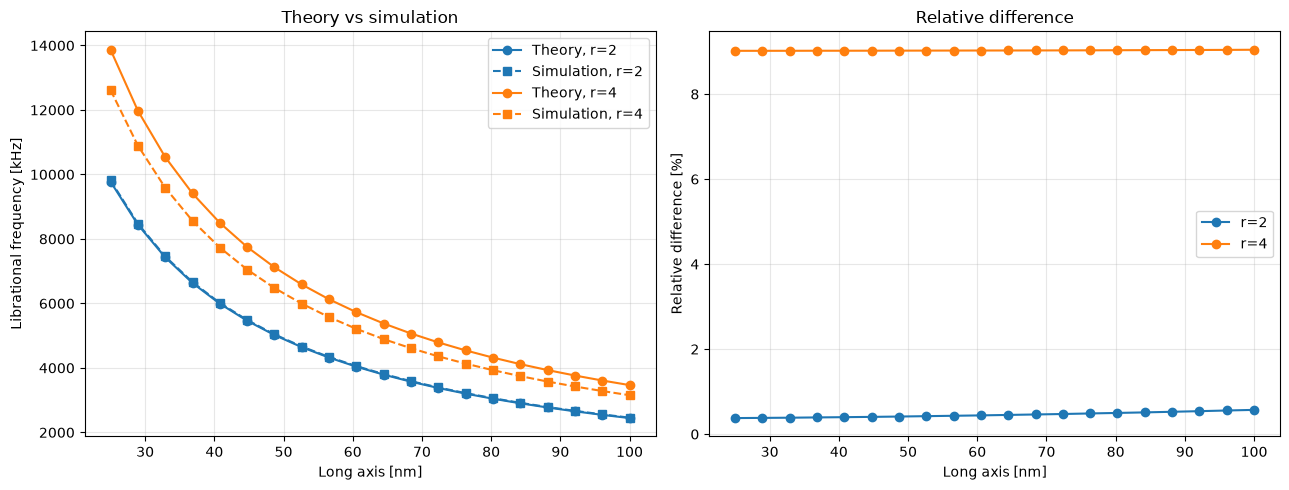

In [13]:
fig, (ax_freq, ax_error) = plt.subplots(1, 2, figsize=(13, 5))
for r, color in [(2, "tab:blue"), (4, "tab:orange")]:
    data = (theo_num_results.loc[theo_num_results["aspect_ratio"] == r].sort_values("long_axis_nm"))
    ax_freq.plot(data["long_axis_nm"], data["theoretical_freq_kHz"], color=color, linestyle="-", marker="o", label=f"Theory, r={r}")
    ax_freq.plot(data["long_axis_nm"], data["simulation_freq_kHz"], color=color, linestyle="--", marker="s", label=f"Simulation, r={r}")
    ax_error.plot(data["long_axis_nm"], data["relative_difference_pct"], color=color, marker="o", label=f"r={r}")
ax_freq.set(xlabel="Long axis [nm]", ylabel="Librational frequency [kHz]", title="Theory vs simulation")
ax_error.set(xlabel="Long axis [nm]", ylabel="Relative difference [%]", title="Relative difference")

for ax in (ax_freq, ax_error):
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()